FAIRNESS - PROJET FINAL




In [53]:
! python -m pip install numpy fairlearn plotly nbformat ipykernel aif360["inFairness"] aif360['AdversarialDebiasing'] causal-learn BlackBoxAuditing cvxpy dice-ml lime shapkit

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nadia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\nadia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pip\_vendor\packaging\requirements.py", line 36, in __init__
    parsed = _parse_requirement(requirement_string)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nadia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pip\_vendor\packaging\_parser.py", line 62, in parse_requirement
    return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nadia\AppData\Local\Packages\PythonSoft

In [ ]:
! python -m pip install numpy fairlearn plotly nbformat ipykernel aif360["inFairness"] aif360['AdversarialDebiasing'] causal-learn BlackBoxAuditing cvxpy dice-ml lime shapkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 67.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**INTRODUCTION**


## **2. Description des Données**





---


Le jeu de données contient les informations cliniques et techniques suivantes pour chaque radiographie :

| Colonne | Description | Type | Rôle dans l'analyse |
| :--- | :--- | :--- | :--- |
| **Image Index** | Identifiant unique du fichier image (ex: `00000001_000.png`). | String | ID Image |
| **Finding Labels** | Les pathologies identifiées par les radiologues (ex: `Cardiomegaly`, `Effusion`). La valeur `No Finding` indique un patient sain. | String | **Variable Cible (Target)** |
| **Follow-up #** | Numéro de suivi de la visite. `0` indique la première visite, `1` la deuxième, etc. | Entier | Temporel / Historique |
| **Patient ID** | Identifiant unique du patient. Permet de regrouper plusieurs images d'une même personne. | Entier | ID Patient |
| **Patient Age** | Âge du patient au moment de l'examen (en années). | Entier | Variable Démographique |
| **Patient Gender** | Sexe du patient (`M` ou `F`). | String | **Variable Protégée (Biais)** |
| **View Position** | Position du patient lors de la radio : <br>- `PA` (Posteroanterior) : Rayon de dos (Patient debout/valide).<br>- `AP` (Anteroposterior) : Rayon de face (Patient souvent alité/complexe). | String | Variable Technique (Biais potentiel) |
| **OriginalImage[Width / Height]** | Largeur et Hauteur de l'image originale en pixels. | Entier | Méta-donnée image |
| **OriginalImagePixelSpacing[x / y]** | Résolution spatiale de l'image (taille physique d'un pixel en mm). | Float | Méta-donnée image |
| **Unnamed: 11** | Colonne vide ou résiduelle issue de l'importation du CSV (souvent due à une virgule traînante). | NaN / String | À ignorer ou à supprimer lors du nettoyage. |
| **train_valid** | Indique si l'image appartient au groupe d'entraînement (train) ou de validation (valid). | String | Partitionnement : Détermine l'usage de la donnée par le modèle. |
| **label** | Traduction simplifiée de Finding Labels en format binaire ou catégoriel (ex: 0 pour Sain, 1 pour Malade). | Entier | Variable Cible (Target) : Ce que le ResNet18 doit apprendre à prédire. |
| **weights** | Valeur numérique attribuée à chaque ligne pour l'entraînement. | Float | Pondération (Pre-processing) : Sert à corriger les déséquilibres et les biais de fairnes |

In [20]:
import pandas as pd
import numpy as np

In [21]:
import pandas as pd
df = pd.read_csv(r'C:\Users\nadia\Downloads\Lesage_Margot\metadata.csv', sep=',')

In [22]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000094_000.png,No Finding,0,94,63,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1
1,00000108_000.png,No Finding,0,108,42,F,PA,2048,2500,0.171,0.171,NaN,train,sain,1
2,00000108_001.png,No Finding,1,108,42,F,AP,2500,2048,0.171,0.171,NaN,train,sain,1
3,00000141_000.png,No Finding,0,141,31,M,PA,2500,2048,0.171,0.171,NaN,train,sain,1
4,00000169_000.png,No Finding,0,169,73,M,PA,2882,2916,0.143,0.143,NaN,train,sain,1


In [23]:
df.dtypes

Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
train_valid                     object
label                           object
WEIGHTS                          int64
dtype: object

## **3. Préparation et Nettoyage des Données (Pre-processing)**

---



Les données brutes issues du monde réel ne sont jamais utilisables telles quelles. Il faut effectuer un nettoyage  :

1.  **Filtrage des aberrances :** Supprimer les patients dont l'âge est supérieur à 100 ans (erreurs de saisie probables qui fausseraient les moyennes).
2.  **Création de la `target` binaire :** La colonne 'Finding Labels' contient du texte complexe (ex: "Hernia|Infiltration"). On peut la simplifier en une variable binaire :
    * **1 (Favorable)** : Le patient est "Sain" (`No Finding`).
    * **0 (Défavorable)** : Le patient a une pathologie quelconque.
3.  **Encodage du Genre :** On transforme la variable catégorielle 'Patient Gender' en format numérique (`M` -> 1, `F` -> 0) pour la rendre compatible avec les algorithmes d'optimisation.

In [79]:
# Check that there is not NaN values
for column in df.columns:
  print(column, df[column].isnull().values.any())

Image Index False
Finding Labels False
Follow-up # False
Patient ID False
Patient Age False
Patient Gender False
View Position False
OriginalImage[Width False
Height] False
OriginalImagePixelSpacing[x False
y] False
Unnamed: 11 True
train_valid False
label False
WEIGHTS False


On selectionne des colonnes. 
On modifie la colonne label, lorsque le patient est malade label vaut 0, dans le cas contraire il vaut 1.

In [80]:




# Sélection des colonnes
features_to_keep = ['Patient ID', 'Patient Age', 'Patient Gender','View Position', 'label', 'WEIGHTS']
df_pro = df[features_to_keep].copy()



# 1. Label : 1 = Sain (Favorable), 0 = Malade
df_pro['label'] = df_pro['label'].apply(lambda x: 1 if x == 'sain' else 0)

# 2. Genre : 1 = Homme (Privilégié), 0 = Femme
df_pro['Patient Gender'] = df_pro['Patient Gender'].map({'M': 1, 'F': 0})



df_pro["View Position"] = df_pro["View Position"].map({'AP': 1, 'PA': 0})
#Pour l'âge on va voir en fonction de si la personne est âgée (selon l'OMS à partir de 60 ans)
df_pro['est_âgée'] = (df_pro['Patient Age'] >= 60).astype(int)


display(df_pro.head())

,Patient ID,Patient Age,Patient Gender,View Position,label,WEIGHTS,est_âgée
0,94,63,1,0,1,1,1
1,108,42,0,0,1,1,0
2,108,42,0,1,1,1,0
3,141,31,1,0,1,1,0
4,169,73,1,0,1,1,1


In [81]:
print(df_pro['Patient Age'].min())
print(df_pro['Patient Age'].max())

2
90


In [82]:
erreurs = df_pro[df_pro['Patient Age'] > 105]
print(len(erreurs))

0


In [83]:
for index, err in erreurs.iterrows():
  print('voici les lignes pour ce patient')
  print(df_pro[df_pro['Patient ID'] == err['Patient ID']])

In [104]:
df_pro.loc[df_pro['Patient Age'] == 149,'Patient Age'] = 46
df.loc[df['Patient Age'] == 149,'Patient Age'] = 46

In [85]:
#on vérifie qu'elles sont plus dans les âges aberrants
erreurs = df_pro[df_pro['Patient Age'] > 105]
erreurs

,Patient ID,Patient Age,Patient Gender,View Position,label,WEIGHTS,est_âgée


C:\Users\nadia\AppData\Local\Temp\ipykernel_71128\1561022170.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_pro, ax=axes[0], palette='pastel')
C:\Users\nadia\AppData\Local\Temp\ipykernel_71128\1561022170.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Patient Gender', data=df_pro, ax=axes[1], palette='Set2') # On utilise df original pour avoir 'M'/'F'


Text(0.5, 1.0, 'Distribution du Genre')

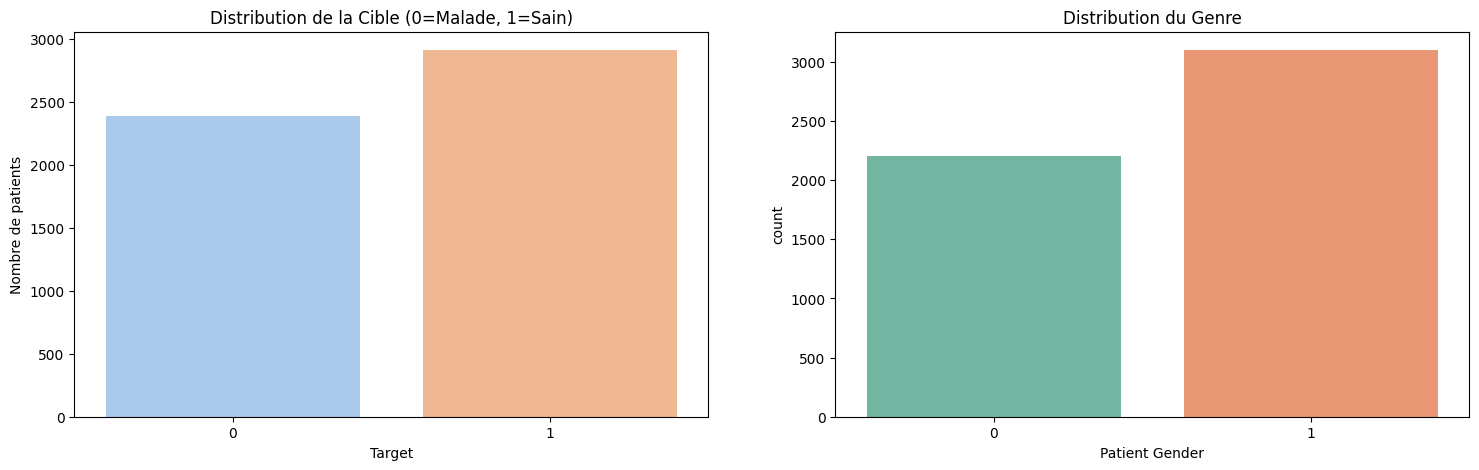

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Distribution des diagnostics (Sain vs Malade)
sns.countplot(x='label', data=df_pro, ax=axes[0], palette='pastel')
axes[0].set_title('Distribution de la Cible (0=Malade, 1=Sain)')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Nombre de patients')

# 2. Distribution du Genre
sns.countplot(x='Patient Gender', data=df_pro, ax=axes[1], palette='Set2') # On utilise df original pour avoir 'M'/'F'
axes[1].set_title('Distribution du Genre')

##III - MITIGATION DES BIAIS PAR PRE PROCESSING :

In [87]:
!pip install aif360

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nadia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [88]:
# Code to compute fairness metrics using aif360

from aif360.sklearn.metrics import *
from sklearn.metrics import  balanced_accuracy_score


# This method takes lists
def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics

In [89]:
#On analyse d'abord les biais inhérents à notre jeu de donnée tel quel par rapport à No Finding:
metrics_baseline_genre = get_metrics(
    y_true=df_pro['label'].values,
    y_pred=df_pro['label'].values,
    prot_attr=df_pro['Patient Gender'],
    priv_group=1 # On définit le groupe privilégié comme étant les hommes dans ce cas
)

metrics_baseline_position = get_metrics(
    y_true=df_pro['label'].values,
    y_pred=df_pro['label'].values,
    prot_attr=df_pro['View Position'],
    priv_group=1 # On définit le groupe privilégié comme étant ceux avec PA
)

metrics_baseline_age = get_metrics(
    y_true=df_pro['label'].values,
    y_pred=df_pro['label'].values,
    prot_attr=df_pro['est_âgée'],
    priv_group=1 # On définit le groupe privilégié comme étant plus de 60
)

In [90]:
print( f"les résultats pour le genre sont {metrics_baseline_genre}")
print( f"les résultats pour la position sont {metrics_baseline_position}")
print(f"les résultats pour l'âge sont {metrics_baseline_age}")

les résultats pour le genre sont {'base_rate_truth': 0.5491046182846371, 'statistical_parity_difference': 0.0032784726793942953, 'disparate_impact_ratio': 1.005985433042475, 'base_rate_preds': 0.5491046182846371, 'equal_opportunity_difference': 0.0, 'average_odds_difference': 0.0, 'conditional_demographic_disparity': 0.0005425975690116422, 'smoothed_edf': 0.007258051971244295, 'df_bias_amplification': 0.0, 'balanced_accuracy_score': 1.0}
les résultats pour la position sont {'base_rate_truth': 0.5491046182846371, 'statistical_parity_difference': 0.10396956982288247, 'disparate_impact_ratio': 1.2147267903181396, 'base_rate_preds': 0.5491046182846371, 'equal_opportunity_difference': 0.0, 'average_odds_difference': 0.0, 'conditional_demographic_disparity': -0.024488468268506147, 'smoothed_edf': 0.22502482072273067, 'df_bias_amplification': 0.0, 'balanced_accuracy_score': 1.0}
les résultats pour l'âge sont {'base_rate_truth': 0.5491046182846371, 'statistical_parity_difference': 0.0956369635

biais dans la position car la statistical_parity_difference est >0.1

on applique maintenant une méthode de **Reweighing**

In [95]:
from sklearn.model_selection import GroupShuffleSplit

# On sépare les données : 80% train, 20% test
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df_pro, groups=df_pro['Patient ID']))
#on met les patients d'un même ID dans le même groupe pour éviter un maximum
#les biais liés à la multiplication d'images par patients

df_train = df_pro.iloc[train_idx]
df_test = df_pro.iloc[test_idx]

X_train, y_train = df_train.drop('label', axis=1), df_train['label']
X_test, y_test = df_test.drop('label', axis=1), df_test['label']

In [96]:
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import BinaryLabelDataset

unprivileged_groups = [{'View Position': 0}] # AP
privileged_groups = [{'View Position': 1}]   # PA

df_train_aif = BinaryLabelDataset(
    df=df_train,
    label_names=['label'],
    protected_attribute_names=['View Position'])

df_test_aif = BinaryLabelDataset(
    df=df_test,
    label_names=['label'],
    protected_attribute_names=['View Position'])

RW = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
RW.fit(df_train_aif)

dataset_review_train = RW.transform(df_train_aif)
dataset_transf_val = RW.transform(df_test_aif)

poids_instance = dataset_review_train.instance_weights

In [102]:
# 1. Initialisation de la colonne avec une valeur par défaut (1.0)
df_pro['poids_rw'] = 1.0
df_pro['WEIGHTS']=1.0
# 2. Insertion des poids calculés uniquement pour le groupe d'entraînement
# On utilise .loc avec les index 'train_idx' pour être ultra précis
df_pro.loc[df_train.index, 'poids_rw'] = poids_instance

In [ ]:
df_pro.head()

,Patient ID,Patient Age,Patient Gender,View Position,label,WEIGHTS,est_âgée,poids_rw
0,94,63,1,0,1,1.0,1,0.923309
1,108,42,0,0,1,1.0,0,0.923309
2,108,42,0,1,1,1.0,0,1.146998
3,141,31,1,0,1,1.0,0,0.923309
4,169,73,1,0,1,1.0,1,0.923309


In [106]:
#on ajoute la ligne dans df pour garder les informations de l'image
# 1. Initialisation de la colonne avec une valeur par défaut (1.0)
df['poids_rw'] = 1.0
df['WEIGHTS']=1.0
# 2. Insertion des poids calculés uniquement pour le groupe d'entraînement
# On utilise .loc avec les index 'train_idx' pour être ultra précis
df.loc[df_train.index, 'poids_rw'] = poids_instance
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS,poids_rw
0,00000094_000.png,No Finding,0,94,63,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1.0,0.923309
1,00000108_000.png,No Finding,0,108,42,F,PA,2048,2500,0.171,0.171,NaN,train,sain,1.0,0.923309
2,00000108_001.png,No Finding,1,108,42,F,AP,2500,2048,0.171,0.171,NaN,train,sain,1.0,1.146998
3,00000141_000.png,No Finding,0,141,31,M,PA,2500,2048,0.171,0.171,NaN,train,sain,1.0,0.923309
4,00000169_000.png,No Finding,0,169,73,M,PA,2882,2916,0.143,0.143,NaN,train,sain,1.0,0.923309


In [109]:
#on le met en csv puis direction collab 
# 1. Sélection des colonnes essentielles pour le projet
# On garde les infos d'origine + les nouvelles colonnes de poids et de groupe
colonnes_finales = [
    'Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 
    'Patient Gender', 'View Position', 'label', 'poids_rw', 
    'WEIGHTS', 'train_valid'
]

# 2. Création d'un nouveau DataFrame filtré
df_rw = df[colonnes_finales].copy()

# 3. Sauvegarde dans un nouveau fichier CSV
# Tu peux le nommer 'metadata_pondere.csv' pour le différencier
poids_rw= "LESAGE_Margot/metadata_rw.csv"

df.to_csv(poids_rw, index=False)

print(f"Nouveau fichier créé : {poids_rw}")
print(f"Colonnes incluses : {list(df_rw.columns)}")

Nouveau fichier créé : LESAGE_Margot/metadata_rw.csv
Colonnes incluses : ['Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'label', 'poids_rw', 'WEIGHTS', 'train_valid']
